## 0. Imports / Constants

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.interaction import CAFInteraction
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters

#Weiner imports
from wienersvd import *
from unfolding_inputs import *

%load_ext autoreload
%autoreload 2

In [25]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

DATA_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both'
PLOT_DIR = f'{DATA_DIR}/plots/{day}/unfolding'
SAVE_DIR = f'{DATA_DIR}/det_var/data'
os.makedirs(SAVE_DIR,exist_ok=True)

PDS_MC_BASE_FNAME = 'mc_small_2_postprocess_pandora.df'
PDS_VARS = ['cv','PMTGainFluct','PMTHighNoise','PMTLowEff']
PDS_FNAMES = [f'pds_var/{v}/{PDS_MC_BASE_FNAME}' for v in PDS_VARS]

SCE_MC_BASE_FNAME = 'mc_small_2_postprocess_pandora.df'
SCE_VARS = ['0xSCE','2xSCE']
SCE_FNAMES = [f'sce_var/{v}/{SCE_MC_BASE_FNAME}' for v in SCE_VARS]

DET_VARS = PDS_VARS + SCE_VARS

PDS_VAR_MC_FNAME = 'pds_var/cv/mc_small_2.df' #For POT accounting
SCE_VAR_MC_FNAME = 'sce_var/0xSCE/mc_small_2.df' #For POT accounting (not a cv file)
MC_FNAMES = [PDS_VAR_MC_FNAME,SCE_VAR_MC_FNAME]


OFFBEAM_FNAME = 'data_offbeam2.df'
DATA_FNAME = 'data_dev2.df'

XSEC_UNIT = 1.020892026801086e-41 #Copied from unfolding, check this

from naming import * #Import naming labels, cut names, shit like dat
print(f'WARNING: Check XSEC_UNIT {XSEC_UNIT:.3e}')

In [7]:
print(PLOT_DIR)
print(SAVE_DIR)

/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/plots/2025_11_14/unfolding
/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/data


In [8]:
# Get keys for h5 files
import h5py
mc_pand_keys = [[] for _ in range(len(PDS_FNAMES)+len(SCE_FNAMES))]
offbeam_pand_keys = []
data_pand_keys = []
mc_inter_keys = [[] for _ in range(len(PDS_FNAMES)+len(SCE_FNAMES))]
offbeam_inter_keys = []
data_inter_keys = []
mcnu_keys = [[] for _ in range(len(PDS_FNAMES)+len(SCE_FNAMES))]
hdr_keys = [[] for _ in range(len(MC_FNAMES))] #Detector systematic headers
offbeam_hdr_keys = []
data_hdr_keys = []

print(mc_pand_keys)
# Check the keys in the H5 Files
for fname in PDS_FNAMES + [OFFBEAM_FNAME,DATA_FNAME,PDS_VAR_MC_FNAME,SCE_VAR_MC_FNAME]+SCE_FNAMES:
  print(f'File: {DATA_DIR}/{fname}')
  with h5py.File(f'{DATA_DIR}/{fname}', 'r') as f:
    # Store all keys at the root level
    for key in f.keys():
      if 'pand' in key:
        if fname in PDS_FNAMES:
          #Find index in PDS_FNAMES
          idx = PDS_FNAMES.index(fname)
          mc_pand_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
      elif 'evt' in key and 'pand' not in key:
        if fname in PDS_FNAMES:
          #Find index in PDS_FNAMES
          idx = PDS_FNAMES.index(fname)
          mc_inter_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_inter_keys.append(key)
        elif fname == DATA_FNAME:
          data_inter_keys.append(key)
      elif 'mcnu' in key:
        if fname in PDS_FNAMES:
          #Find index in PDS_FNAMES
          idx = PDS_FNAMES.index(fname)
          mcnu_keys[idx].append(key)
      elif 'hdr' in key:
        if fname in MC_FNAMES:
          idx = MC_FNAMES.index(fname)
          hdr_keys[idx].append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
print(mc_pand_keys,offbeam_pand_keys,mc_inter_keys,offbeam_inter_keys,mcnu_keys,hdr_keys)

[[], [], [], [], [], []]
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/cv/mc_small_2_postprocess_pandora.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/PMTGainFluct/mc_small_2_postprocess_pandora.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/PMTHighNoise/mc_small_2_postprocess_pandora.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/PMTLowEff/mc_small_2_postprocess_pandora.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/data_offbeam2.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/data_dev2.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/pds_var/cv/mc_small_2.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/both/sce_var/0xSCE/mc_small_2.df
File: /exp/sbnd/data/users/brindenc/analyze_s

In [9]:
hdr_keys

[['hdr_0'], ['hdr_0']]

In [ ]:
LIVETIME_DATA = 9.51e5 # From medulla
#POT for all detvar samples
POT_MCS = [0 for _ in range(len(MC_FNAMES))]
for idx,keys in enumerate(hdr_keys):
  for i,key in enumerate(keys):
    POT_MCS[idx] += pd.read_hdf(f'{DATA_DIR}/{MC_FNAMES[idx]}',key=key).pot.sum()
#OFFBEAM POT
LIVETIME_DATAOFFBEAM = 0
for key in offbeam_hdr_keys:
  LIVETIME_DATAOFFBEAM += pd.read_hdf(f'{DATA_DIR}/{OFFBEAM_FNAME}',key=key).noffbeambnb.sum()
POT_DATA = 0
#LIVETIME_DATA = 0
for key in data_hdr_keys:
  _hdr_df = pd.read_hdf(f'{DATA_DIR}/{DATA_FNAME}',key=key)
  POT_DATA += _hdr_df.pot.sum()
  #LIVETIME_DATA += _hdr_df.noffbeambnb.sum()

#Get POT label
pot_mag = int(np.floor(np.log10(POT_DATA)))
pot_base = POT_DATA/10**pot_mag
POT_LABEL = f'{pot_base:.2f} x 10$^{{{pot_mag}}}$ POT'
print(f'data POT: {POT_LABEL}, mc POTs: {POT_MCS}, offbeam livetime: {LIVETIME_DATAOFFBEAM:.2e}, data livetime: {LIVETIME_DATA:.2e}')

NameError: name 'POT_MC' is not defined

In [28]:
POT_MCS

[1.5086107674133135e+18, 1.492579200685572e+18]

In [11]:
data_pand_keys

['evt_pand_0']

In [12]:
slcs = []
for i,fname in tqdm(enumerate(PDS_FNAMES+SCE_FNAMES),desc='Loading slices',unit=' goomba'):
  slcs.append(CAFSlice.load(f"{DATA_DIR}/{fname}",key='pandora'))
#Split into PDS and SCE slices
slcs_pdsvar = slcs[:len(PDS_FNAMES)]
slcs_scevar = slcs[len(PDS_FNAMES):]
#slc_data = CAFSlice.load(f"{DATA_DIR}/{DATA_FNAME}",key='pandora')

Loading slices: 0 goomba [00:00, ? goomba/s]

Loading slices: 6 goomba [06:17, 62.88s/ goomba]


In [13]:
#Get list of slices with all cuts applied
slcs_pdsvar_all_cuts = [s.copy() for s in slcs_pdsvar]
[s.cut_all(cut=True) for s in slcs_pdsvar_all_cuts]

slcs_scevar_all_cuts = [s.copy() for s in slcs_scevar]
[s.cut_all(cut=True) for s in slcs_scevar_all_cuts]

slcs_all_cuts = slcs_pdsvar_all_cuts + slcs_scevar_all_cuts

## 2. Event rates for each sample

In [14]:
costheta_bins = np.arange(-1,1.1,0.1)
mom_bins = np.hstack((np.arange(0,2.6,0.1),[1e10]))

#Get distribution after all cuts
reco_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs_all_cuts]
reco_moms = [s.data.mu.pfp.trk.P.p_muon for s in slcs_all_cuts]
genweights = [s.data.genweight for s in slcs_all_cuts]


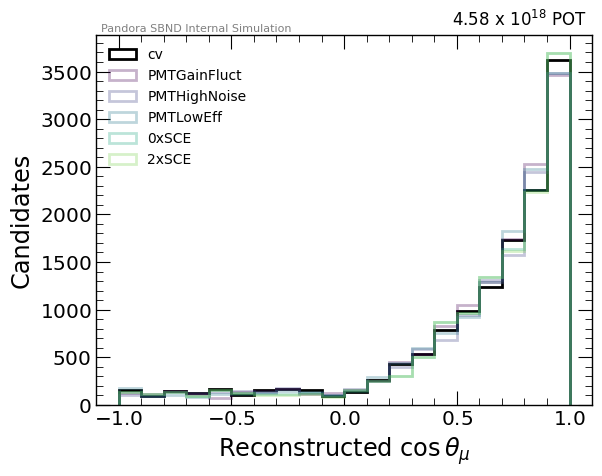

In [17]:
#Costheta
reco_costhetas_event_counts = []
rct_colors = plotters.get_colors('viridis',len(DET_VARS)-1,max_color=0.8)
fig,ax = plt.subplots()
for i,rct in enumerate(reco_costhetas):
  alpha = 1. if i == 0 else 0.3
  color = rct_colors[i-1] if i > 0 else 'black'
  c,_,_ = ax.hist(rct,bins=costheta_bins,weights=genweights[i],label=f'{DET_VARS[i]}',histtype='step',alpha=alpha,color=color)
  reco_costhetas_event_counts.append(c)
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_ylabel('Candidates')
ax.legend()
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
plotters.save_plot('reco_costheta',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')


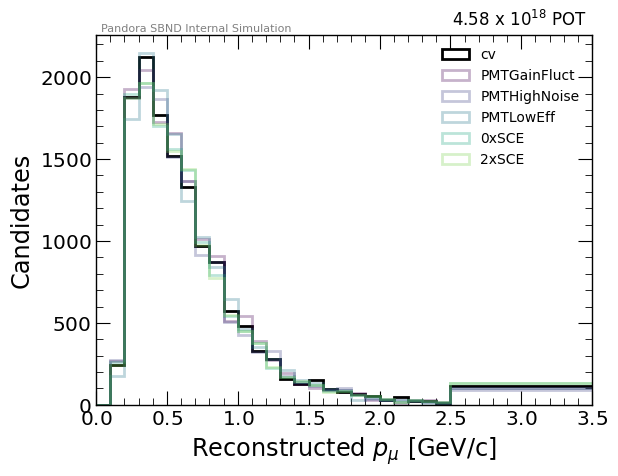

In [18]:
#Momentum
reco_moms_event_counts = []
fig,ax = plt.subplots()
mom_colors = plotters.get_colors('viridis',len(DET_VARS)-1,max_color=0.8)
for i,mom in enumerate(reco_moms):
  color = mom_colors[i-1] if i > 0 else 'black'
  alpha = 1. if i == 0 else 0.3
  c,_,_ = ax.hist(mom,bins=mom_bins,weights=genweights[i],label=f'{DET_VARS[i]}',histtype='step',alpha=alpha,color=color)
  reco_moms_event_counts.append(c)
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV/c]')
ax.set_ylabel('Candidates')
ax.set_xlim(0,3.5)
ax.legend()
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01),fontsize=8,color='gray')
plotters.save_plot('reco_pmu',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')

## 3. Construct covariance matrix

In [19]:
from sbnd.stats.stats import construct_covariance

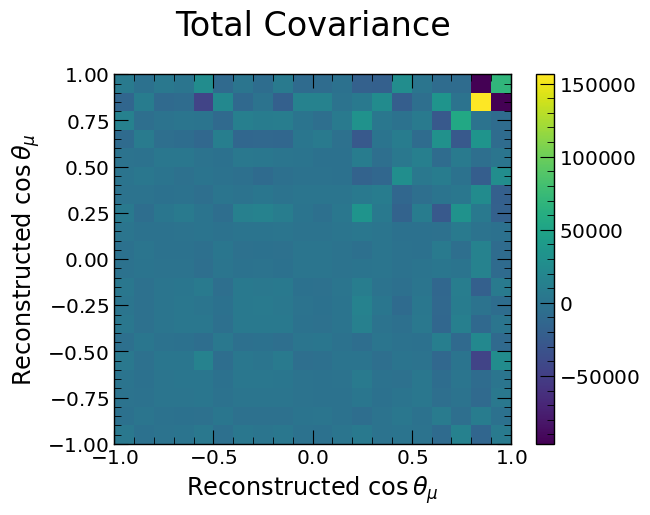

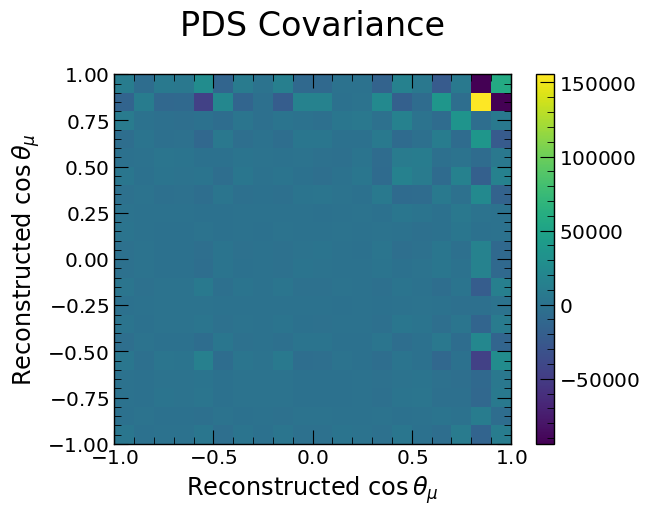

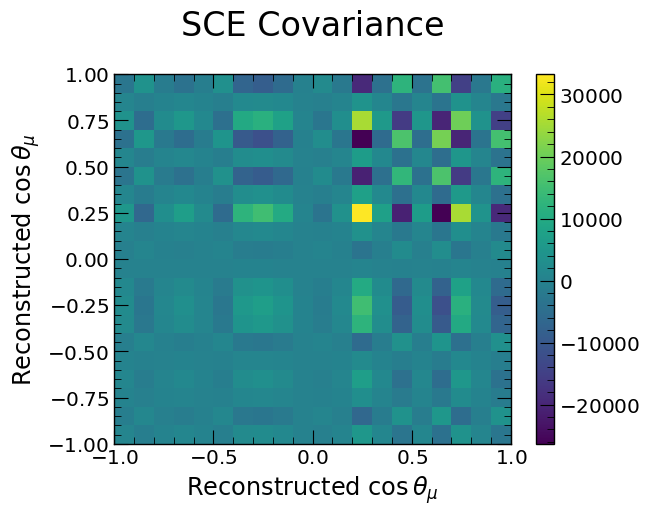

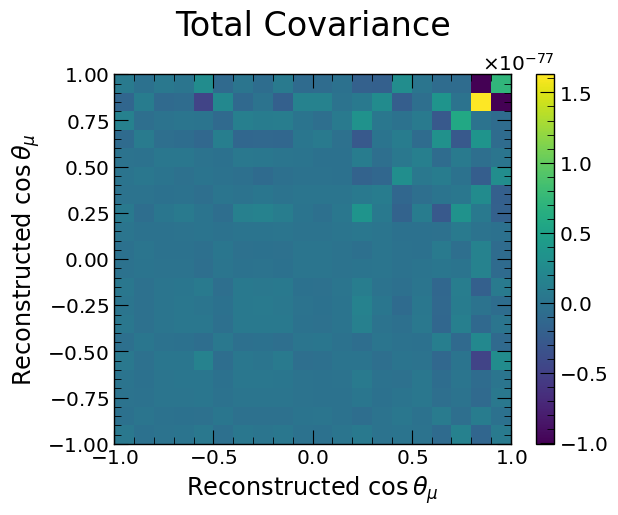

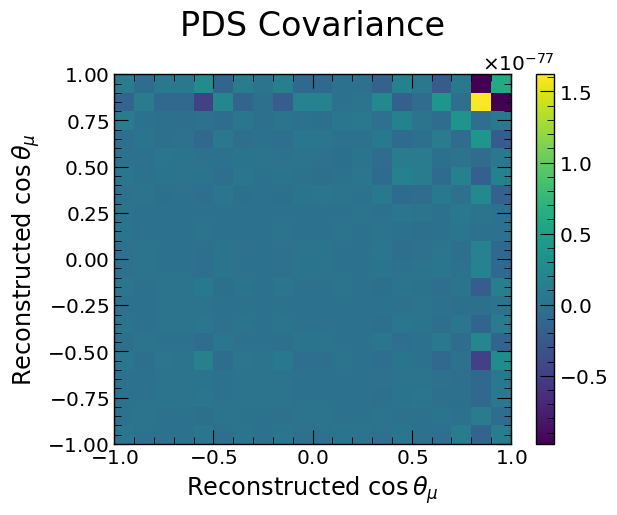

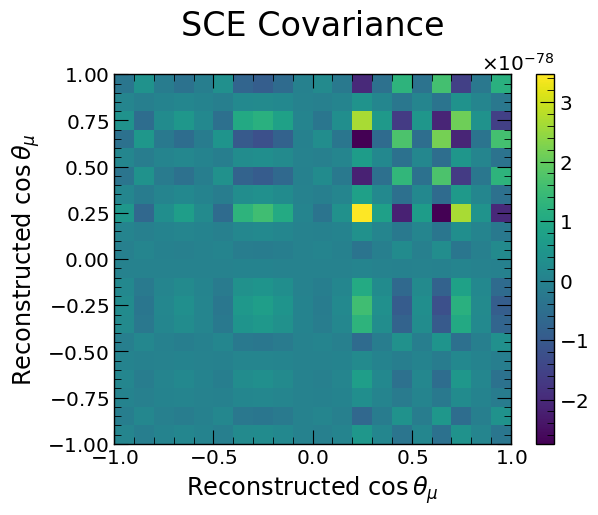

In [29]:
scale_labels = ['noscale','xsecunit']
tot_cov_names = ['tot_cov','pds_tot_cov','sce_tot_cov']
tot_cov_labels = ['Total','PDS','SCE']
for i,scale in enumerate([1.,XSEC_UNIT]):
  #Costheta
  tot_cov = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
  pds_tot_cov = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
  sce_tot_cov = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
  for ind,det_var in enumerate(DET_VARS):
    if ind == 0: continue
    cov = construct_covariance(reco_costhetas_event_counts[0],[reco_costhetas_event_counts[ind]],scale_cov=scale)
    tot_cov += cov
    if det_var in PDS_VARS:
      pds_tot_cov += cov
    else:
      sce_tot_cov += cov
    fig,ax = plt.subplots()
    im = ax.pcolormesh(costheta_bins,costheta_bins,cov,cmap='viridis')
    ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
    ax.set_ylabel(r'Reconstructed $\cos\theta_\mu$')
    ax.set_title(f'{DET_VARS[ind]} Covariance')
    fig.colorbar(im,ax=ax)
    plt.close(fig)
    plotters.save_plot(f'reco_costheta_cov_{DET_VARS[ind]}_{scale_labels[i]}',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')
    np.savetxt(f'{SAVE_DIR}/reco_costheta_cov_{DET_VARS[ind]}_{scale_labels[i]}.txt',cov)
  #Lazy AI slop copy from top to this
  for j,cov in enumerate([tot_cov,pds_tot_cov,sce_tot_cov]):
    fig,ax = plt.subplots()
    im = ax.pcolormesh(costheta_bins,costheta_bins,cov,cmap='viridis')
    ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
    ax.set_ylabel(r'Reconstructed $\cos\theta_\mu$')
    ax.set_title(f'{tot_cov_labels[j]} Covariance')
    fig.colorbar(im,ax=ax)
    plt.show()
    plotters.save_plot(f'reco_costheta_{tot_cov_names[j]}_{scale_labels[i]}',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')
    np.savetxt(f'{SAVE_DIR}/reco_costheta_{tot_cov_names[j]}_{scale_labels[i]}.txt',cov)

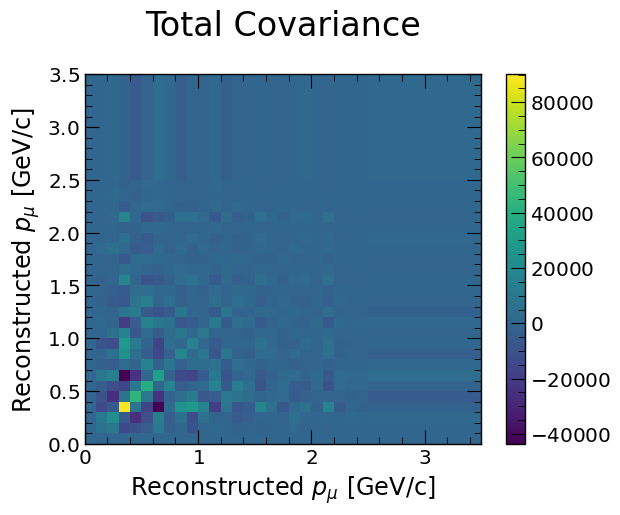

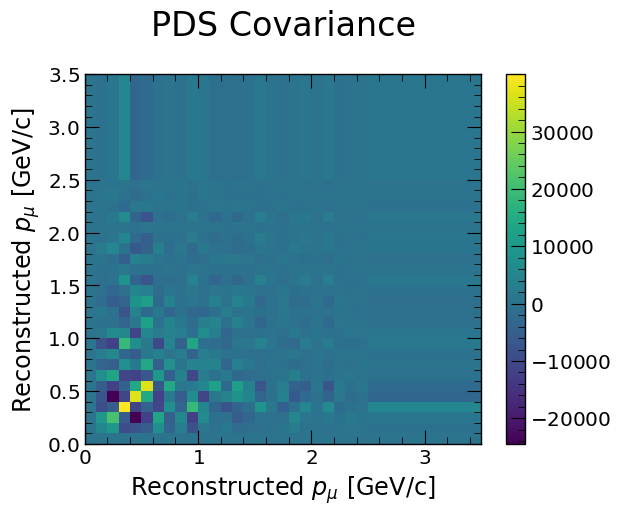

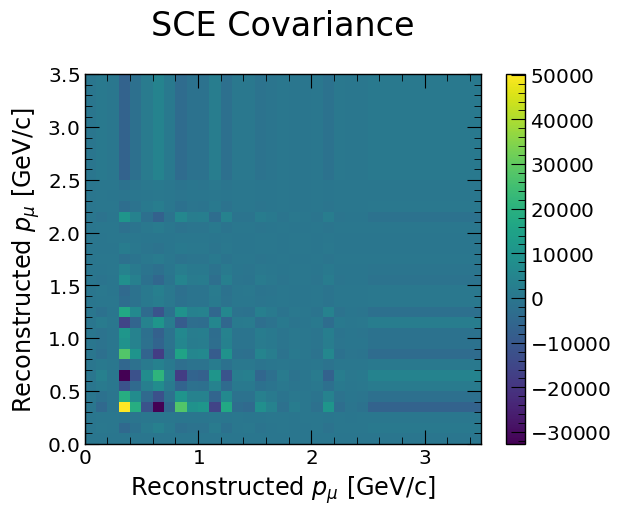

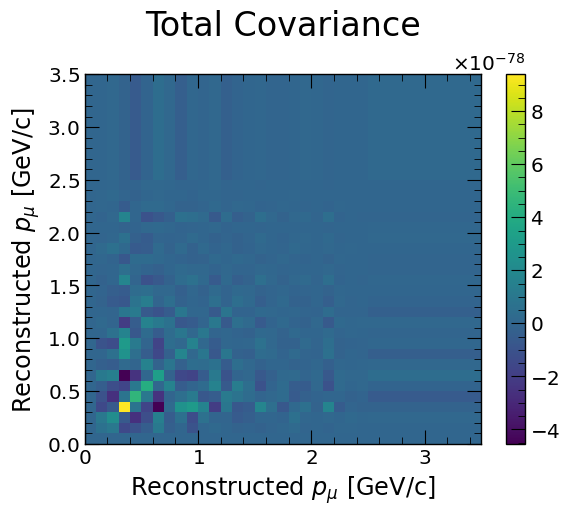

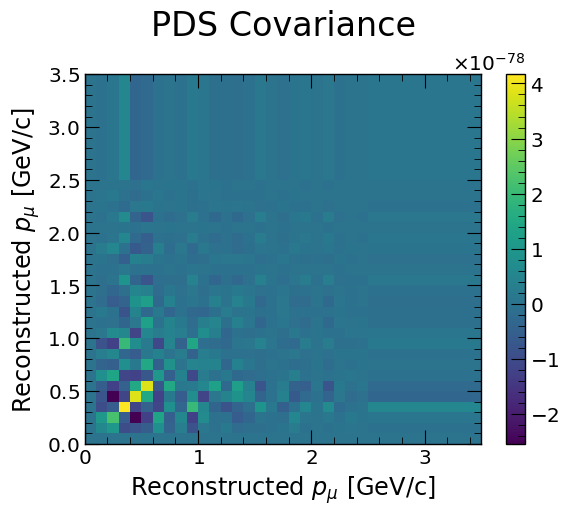

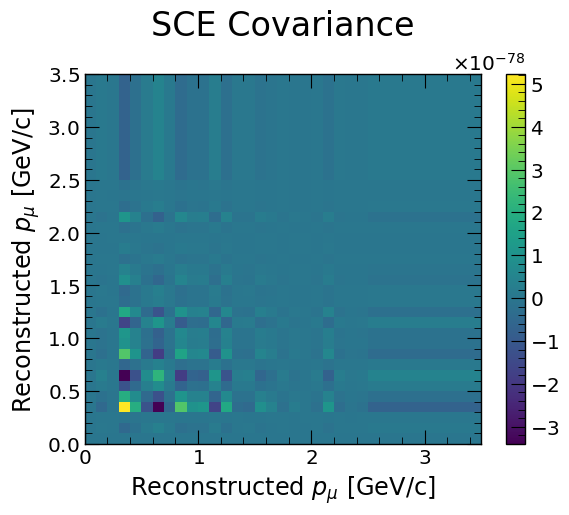

In [30]:
scale_labels = ['noscale','xsecunit']
tot_cov_names = ['tot_cov','pds_tot_cov','sce_tot_cov']
tot_cov_labels = ['Total','PDS','SCE']
for i,scale in enumerate([1.,XSEC_UNIT]):
  #Momentum
  tot_cov = np.zeros((len(mom_bins)-1,len(mom_bins)-1))
  pds_tot_cov = np.zeros((len(mom_bins)-1,len(mom_bins)-1))
  sce_tot_cov = np.zeros((len(mom_bins)-1,len(mom_bins)-1))
  for ind,det_var in enumerate(DET_VARS):
    if ind == 0: continue
    cov = construct_covariance(reco_moms_event_counts[0],[reco_moms_event_counts[ind]],scale_cov=scale)
    tot_cov += cov
    if det_var in PDS_VARS:
      pds_tot_cov += cov
    else:
      sce_tot_cov += cov
    fig,ax = plt.subplots()
    im = ax.pcolormesh(mom_bins,mom_bins,cov,cmap='viridis')
    ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV/c]')
    ax.set_ylabel(r'Reconstructed $p_\mu$ [GeV/c]')
    ax.set_title(f'{DET_VARS[ind]} Covariance')
    ax.set_xlim(0,3.5)
    ax.set_ylim(0,3.5)
    fig.colorbar(im,ax=ax)
    plt.close(fig)
    plotters.save_plot(f'reco_mom_cov_{DET_VARS[ind]}_{scale_labels[i]}',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')
    np.savetxt(f'{SAVE_DIR}/reco_mom_cov_{DET_VARS[ind]}_{scale_labels[i]}.txt',cov)
  #Lazy AI slop copy from top to this
  for j,cov in enumerate([tot_cov,pds_tot_cov,sce_tot_cov]):
    fig,ax = plt.subplots()
    im = ax.pcolormesh(mom_bins,mom_bins,cov,cmap='viridis')
    ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV/c]')
    ax.set_ylabel(r'Reconstructed $p_\mu$ [GeV/c]')
    ax.set_title(f'{tot_cov_labels[j]} Covariance')
    ax.set_xlim(0,3.5)
    ax.set_ylim(0,3.5)
    fig.colorbar(im,ax=ax)
    plt.show()
    plotters.save_plot(f'reco_mom_{tot_cov_names[j]}_{scale_labels[i]}',fig=fig,folder_name=PLOT_DIR+'/pandora/det_var/')
    np.savetxt(f'{SAVE_DIR}/reco_mom_{tot_cov_names[j]}_{scale_labels[i]}.txt',cov)

## 3. Event rates by event type for each slice

In [50]:
slcs_evttype = [[] for _ in range(len(PDS_FNAMES))]
for i, _slc in tqdm(enumerate(slcs), desc='Grouping by event type', unit=' goomba'):
    slc_event_type_col = _slc.get_key('truth.event_type')
    slc_groups = _slc.data.groupby(slc_event_type_col)

    for key, val in EVENT_TYPE_LIST.items():
        if key in slc_groups.groups:
            slcs_evttype[i].append(CAFSlice(slc_groups.get_group(key)))
      
      # if key in inter_groups.groups:
      #     inters.append(CAFInteraction(inter_groups.get_group(key)))

Grouping by event type: 0 goomba [00:00, ? goomba/s]

/tmp/ipykernel_90704/1099360890.py:8: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs_evttype[i].append(CAFSlice(slc_groups.get_group(key)))
Grouping by event type: 4 goomba [00:21,  5.47s/ goomba]


In [51]:
slcs_evttype[0]

In [52]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
    if key == -1: #no unknown for now
        continue
    labels.append(item[0])
    names.append(item[1])
    colors.append(item[2])

slc_weights = []
for i,slc_group in tqdm(enumerate(slcs_evttype),desc='Getting weights',unit='goomba'):
  print(f' type slc_group: {type(slc_group)}')
  _slc_weights = [s.data.genweight for s in slc_group]
  slc_weights.append(_slc_weights)
  #inter_weights = [i.data.genweight for i in inters]

#Assert no nans in weights
for _slc_weights in slc_weights:
  assert [any(np.isnan(_slc_weights))].count(True) == 0

Getting weights: 0goomba [00:00, ?goomba/s]

Getting weights: 4goomba [00:00, 24.79goomba/s]

 type slc_group: <class 'list'>
 type slc_group: <class 'list'>
 type slc_group: <class 'list'>
 type slc_group: <class 'list'>


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

## Testing

In [32]:
hdr = pd.read_hdf(f'{DATA_DIR}/{MC_FNAME}',key='hdr_0')

In [26]:
hdr.pot.sum()

1.5086108e+18